In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
val = pd.read_parquet('data/val.parquet')

In [3]:
x_cols = ['Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y', 
          'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count', 
          'Packet speed_y_normalized', 'Data speed_y_normalized', 'time_of_day',
          'Avg packet len_y_normalized', 'total_seconds', 'weekday_number', 
          'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 
          'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount', 
          'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 
          'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 
          'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 
          'Is_DNS', 'Is_POP3', 'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 
          'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 'Is_TFTP', 'Is_MySQL', 
          'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081', 
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 
          'Is_NTP', 'Is_Kerberos', 'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 
          'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 'Is_BGP', 'Is_IMAPS_Alt', 
          'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 
          'Is_Modbus', 'Is_CoAP', 'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 
          'Is_Elasticsearch', 'Is_Zookeeper', 'Is_Cassandra', 'Is_Docker', 
          'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 'Is_DHCPv6', 
          'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH']

# Voting


In [4]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Assuming you have your data loaded into 'train' and 'test' DataFrames
# and 'x_cols' is a list of feature column names.

# Separate features (X) and target (y) for training and testing
X_train = train[x_cols]
y_train = train['Type']
X_test = test[x_cols]
y_test = test['Type']

# Initialize the individual classifiers
rf_clf = RandomForestClassifier(n_estimators=437, random_state=42, max_depth=37, min_samples_split=10, min_samples_leaf=5, verbose=0)
lgbm_clf = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
xgb_clf = xgb.XGBClassifier(objective='multi:softmax', num_class=3,booster=('gbtree'),alpha=0.8929914624140356,subsample=0.5245590585473099,colsample_bytree=0.41745486572446977,max_depth=10,eta=0.03343544751435021,gamma=0.36103800824329335,grow_policy='lossguide',min_child_weight=2,eval_metric='merror',  random_state=42,)

# Create the voting classifier (soft voting requires probability estimates)
voting_clf_soft = VotingClassifier(
    estimators=[('rf', rf_clf), ('lgbm', lgbm_clf), ('xgb', xgb_clf)],
    voting='soft'
)

In [5]:
# Train the voting classifier
voting_clf_soft.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=37,
                                                     min_samples_leaf=5,
                                                     min_samples_split=10,
                                                     n_estimators=437,
                                                     random_state=42)),
                             ('lgbm',
                              LGBMClassifier(colsample_bytree=0.9577482057904019,
                                             learning_rate=0.05719243532859288,
                                             max_depth=5, min_child_samples=42,
                                             n_estimators=351, num_leaves=47,
                                             random_state=42,
                                             subsample=0.8896113748808988,
                                             ve...
                                            gamma=0.36103800824329335,
                                            grow_policy='lossguide',
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=10,
                                            max_leaves=None, min_child_weight=2,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None, ...))],
                 voting='soft')


Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.96      0.78    636601
           1       0.92      0.95      0.94   1421249
           2       0.86      0.08      0.15    388837

    accuracy                           0.82   2446687
   macro avg       0.81      0.67      0.62   2446687
weighted avg       0.84      0.82      0.77   2446687



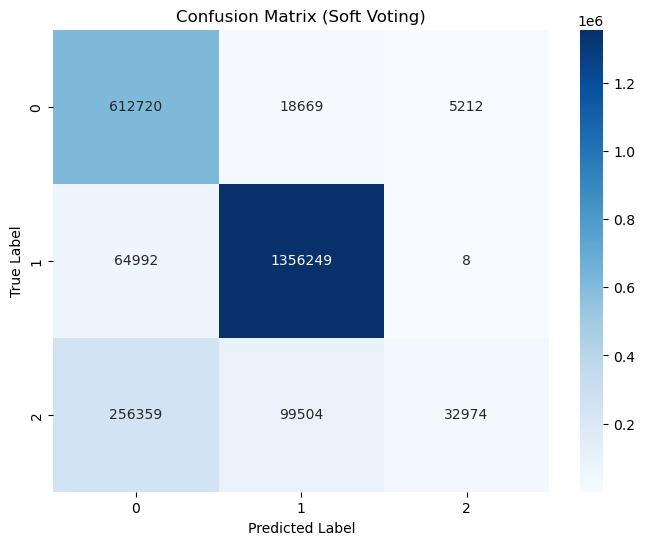


Confusion Matrix:
[[ 612720   18669    5212]
 [  64992 1356249       8]
 [ 256359   99504   32974]]


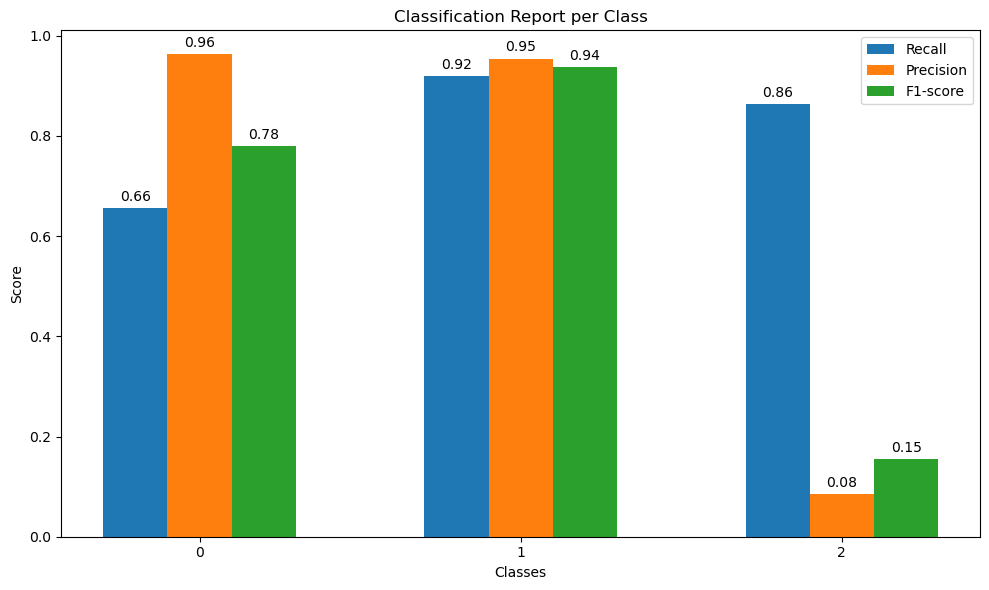

Accuracy: 0.8182260338163402
Precision: 0.8130492963520614
Recall: 0.6671846288311668


TypeError: 'list' object is not callable

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# Make predictions on the test set
test['pred_soft'] = voting_clf_soft.predict(test[x_cols])


# Generate the classification report
report_soft = classification_report(test['Type'], test['pred_soft'])
print("\nClassification Report:")
print(report_soft)

# Generate the confusion matrix
cm_soft = confusion_matrix(test['Type'], test['pred_soft'])

# Visualize the confusion matrix
class_labels_soft = np.unique(test['Type'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_soft, yticklabels=class_labels_soft)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Soft Voting)')
plt.show()

# Print the confusion matrix (textual representation)
print("\nConfusion Matrix:")
print(cm_soft)

report = classification_report(test['Type'], test['pred_soft'], output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()

accuracy = accuracy_score(test['Type'], test['pred_soft'])
print("Accuracy:", accuracy)
precision = precision_score(test['Type'], test['pred_soft'], average='macro')
print("Precision:", precision)
recall = recall_score(test['Type'], test['pred_soft'], average='macro')
print("Recall:", recall)
f1 = f1_score(test['Type'], test['pred_soft'], average='macro')
print("F1-Score:", f1)

In [10]:
# Optional: Evaluate Hard Voting Classifier as well
voting_clf_hard = VotingClassifier(
    estimators=[('rf', rf_clf), ('lgbm', lgbm_clf), ('xgb', xgb_clf)],
    voting='hard',
    flatten_transform=True 
)

voting_clf_hard.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=37,
                                                     min_samples_leaf=5,
                                                     min_samples_split=10,
                                                     n_estimators=437,
                                                     random_state=42)),
                             ('lgbm',
                              LGBMClassifier(colsample_bytree=0.9577482057904019,
                                             learning_rate=0.05719243532859288,
                                             max_depth=5, min_child_samples=42,
                                             n_estimators=351, num_leaves=47,
                                             random_state=42,
                                             subsample=0.8896113748808988,
                                             ve...
                                            feature_types=None,
                                            gamma=0.36103800824329335,
                                            grow_policy='lossguide',
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=10,
                                            max_leaves=None, min_child_weight=2,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None, ...))])

In [11]:
pred_hard = voting_clf_hard.predict(test[x_cols])

In [16]:
pred_hard = voting_clf_hard.predict(val[x_cols])


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.97      0.78    636601
           1       0.92      0.95      0.94   1421249
           2       0.83      0.06      0.11    388837

    accuracy                           0.82   2446687
   macro avg       0.80      0.66      0.61   2446687
weighted avg       0.84      0.82      0.77   2446687



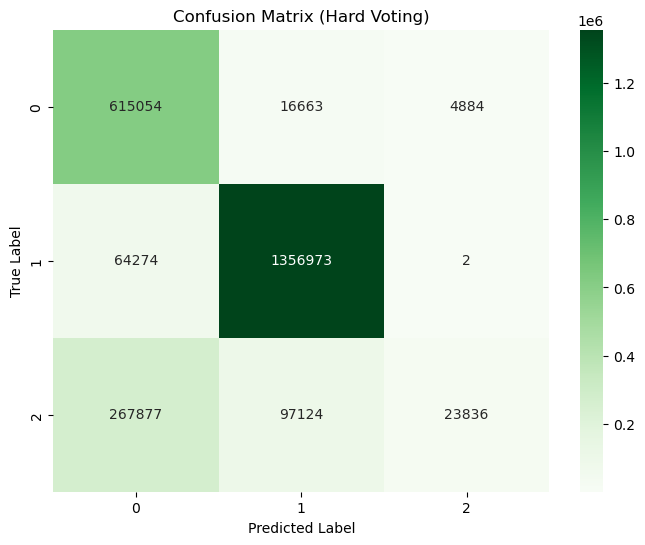


Confusion Matrix:
[[ 615054   16663    4884]
 [  64274 1356973       2]
 [ 267877   97124   23836]]


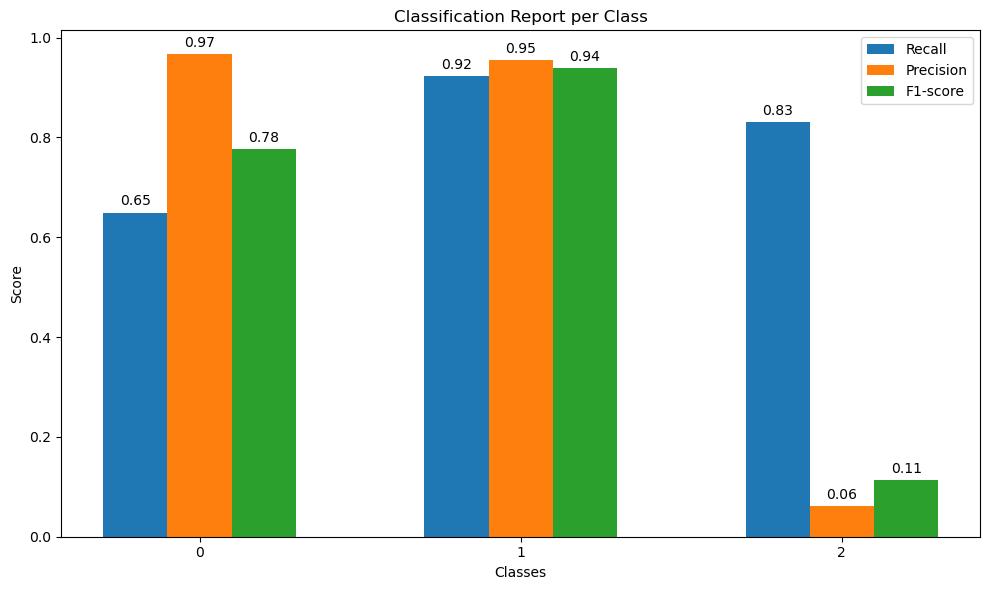

In [18]:
report_hard = classification_report(val['Type'], pred_hard)
print("\nClassification Report:")
print(report_hard)

cm_hard = confusion_matrix(val['Type'], pred_hard)
class_labels_hard = np.unique(val['Type'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels_hard, yticklabels=class_labels_hard)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Hard Voting)')
plt.show()

print("\nConfusion Matrix:")
print(cm_hard)

report = classification_report(val['Type'], pred_hard, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()

# Stacking


In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import StackingClassifier
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder

# Define the base models
rf_model = RandomForestClassifier(random_state=42)
lgbm_model = lgb.LGBMClassifier(random_state=42)

# Define the Keras model
input_shape = (len(x_cols), 1)
keras_model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Dense(units=256, activation='relu'),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=3, activation='softmax') # Output units should match the number of classes
])

# The StackingClassifier expects scikit-learn compatible estimators.
# Keras models need a wrapper to be used with scikit-learn.
from sklearn.neural_network import MLPClassifier # A simple scikit-learn neural network

# Define the stacking classifier
estimators = [
    ('rf', rf_model),
    ('lgbm', lgbm_model),
    # We'll use a scikit-learn neural network for the stacking meta-learner
    ('nn', MLPClassifier(random_state=42, max_iter=300))
]
stacking_model = StackingClassifier(estimators=estimators, final_estimator=keras_model)

# Train the stacking model
# Note: Training a Keras model as the final estimator within StackingClassifier
# might not work directly with the standard StackingClassifier.
# We'll train the base models and then use their predictions to train the Keras model separately.

# Train the base models
rf_model.fit(train[x_cols], train['Type'])
lgbm_model.fit(train[x_cols], train['Type'])

# Get predictions from base models on the training data (for meta-learner training)
rf_train_pred = rf_model.predict_proba(train[x_cols])
lgbm_train_pred = lgbm_model.predict_proba(train[x_cols])

# Create the training data for the Keras meta-learner
meta_train_data = np.concatenate((rf_train_pred, lgbm_train_pred), axis=1)

# Train the Keras meta-learner
keras_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Ensure train['Type'] is 1D
y_keras = train['Type'].values.flatten() if len(train['Type'].shape) > 1 and train['Type'].shape[1] == 1 else train['Type']

keras_model.fit(meta_train_data, y_keras, epochs=10, batch_size=32, validation_split=0.2)


# Get predictions from base models on the test data
rf_test_pred = rf_model.predict_proba(test[x_cols])
lgbm_test_pred = lgbm_model.predict_proba(test[x_cols])

# Create the test data for the Keras meta-learner
meta_test_data = np.concatenate((rf_test_pred, lgbm_test_pred), axis=1)

# Make predictions with the Keras meta-learner
y_pred_stacked_proba = keras_model.predict(meta_test_data)
y_pred_stacked = np.argmax(y_pred_stacked_proba, axis=1)

# Evaluate the stacked model
accuracy_stacked = f1_score(test['Type'], y_pred_stacked)
print(f"Accuracy of the Stacking Model (with Keras meta-learner): {accuracy_stacked:.4f}")

# Evaluate the base models individually
y_pred_rf = rf_model.predict(test[x_cols])
accuracy_rf = f1_score(test['Type'], y_pred_rf)
print(f"Accuracy of Random Forest: {accuracy_rf:.4f}")

y_pred_lgbm = lgbm_model.predict(test[x_cols])
accuracy_lgbm = f1_score(test['Type'], y_pred_lgbm)
print(f"Accuracy of LightGBM: {accuracy_lgbm:.4f}")

Epoch 1/10


ValueError: Arguments `target` and `output` must have the same shape up until the last dimension: target.shape=(None, 1), output.shape=(None, 6, 3)